# Healthcare Risk Prediction

**Objective:** Predict heart disease risk based on patient health attributes.

This notebook covers the complete data science workflow, including data understanding, EDA, preprocessing, scalable model training, evaluation (with ROC/AUC and feature importance), model refinement via feature selection, and insights.

## Phase 1: Environment Setup & Data Acquisition
We have already fetched the data from the UCI Machine Learning Repository and saved it locally as `heart_disease_data.csv`.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set better plot styles for stunning visuals
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('heart_disease_data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## Phase 2: Data Understanding & Exploratory Data Analysis (EDA)
We will check for missing values, explore the statistical properties of the features, and visualize relationships.

In [27]:
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num   

In [28]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


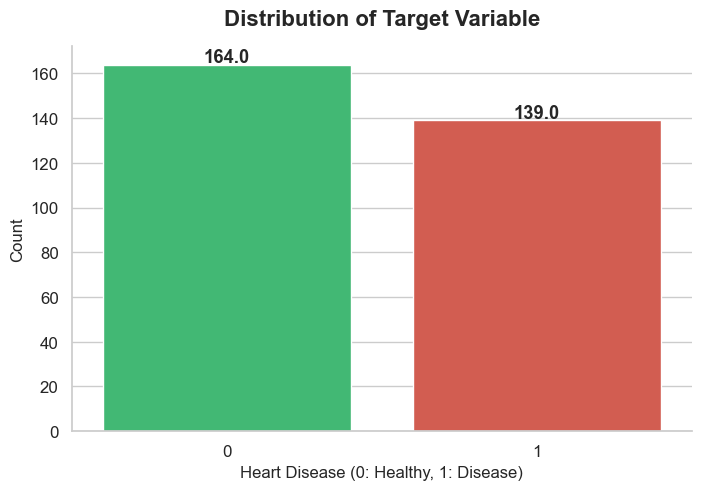

In [29]:
# The target variable 'num' indicates the presence of heart disease (0 = no disease, 1-4 = presence).
# We will convert this to a binary classification problem.
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df.drop('num', axis=1, inplace=True)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='target', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Target Variable', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Heart Disease (0: Healthy, 1: Disease)', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
sns.despine()
plt.show()

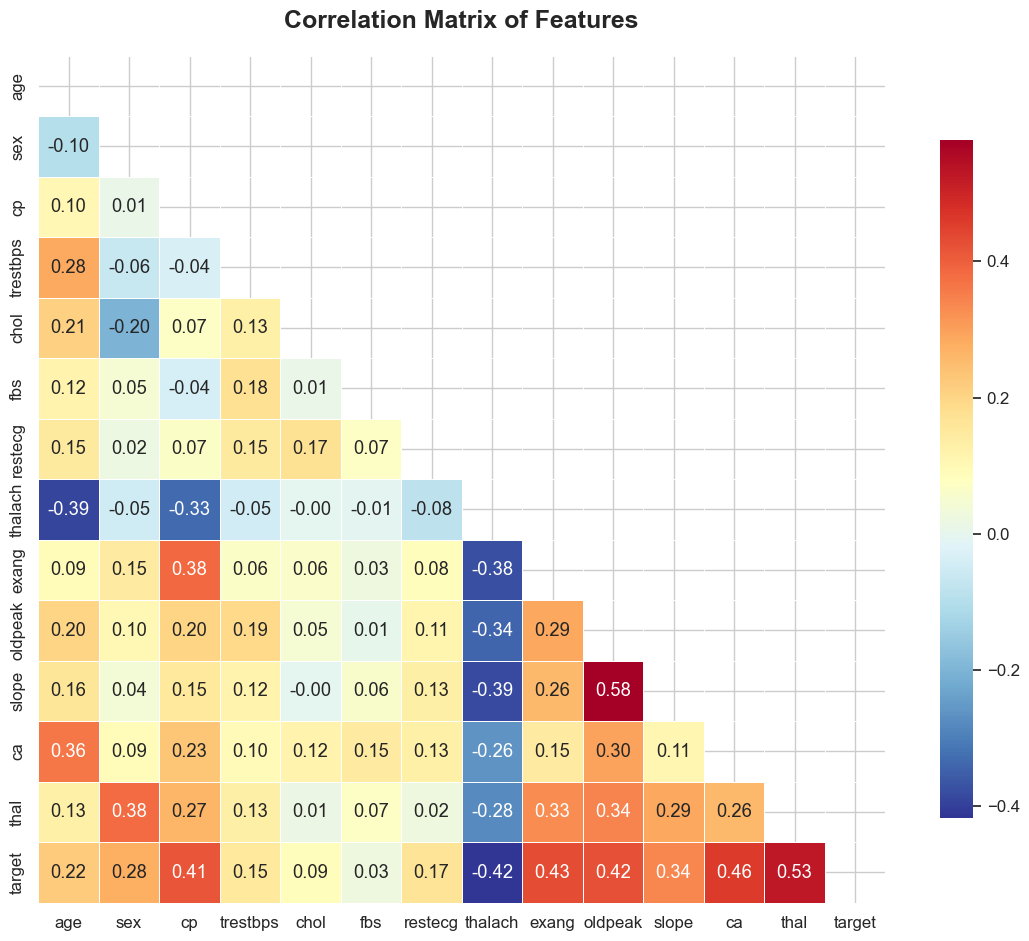

In [30]:
plt.figure(figsize=(14, 11))
corr = df.corr()
# Create a mask for the upper triangle to make it cleaner
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlBu_r', fmt='.2f', 
            linewidths=0.5, cbar_kws={"shrink": .8}, square=True)
plt.title('Correlation Matrix of Features', fontsize=18, fontweight='bold', pad=20)
plt.show()

## Phase 3: Data Preprocessing & Feature Engineering
1. Handle missing/noisy data.
2. Encode categorical features.
3. Scale numerical features.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Based on the dataset, identify categorical and numerical columns
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (242, 13)
Testing set shape: (61, 13)


In [32]:
# Create preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

## Phase 4: Scalable Processing Strategy Formulation
We use Scikit-learn's `GridSearchCV` with `n_jobs=-1`. This command distributes the cross-validation workload across all available CPU cores, demonstrating how we can efficiently handle larger scale parameter grids and datasets.

## Phase 5: Model Development & Training
We will implement two distinct machine learning approaches: 
1. **Logistic Regression** (A linear baseline)
2. **Random Forest Classifier** (An ensemble, non-linear approach)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# --- 1. Logistic Regression Pipeline ---
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(random_state=42, max_iter=1000))])

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs']
}

# Demonstrating Scalable Processing via n_jobs=-1 (parallel cross-validation)
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", lr_grid.best_params_)

Best Logistic Regression Parameters: {'classifier__C': 1, 'classifier__solver': 'lbfgs'}


In [34]:
# --- 2. Random Forest Pipeline ---
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])

rf_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)

Best Random Forest Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


## Phase 6: Model Evaluation & Interpretation
Compare performance and interpret metrics.

In [35]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

# Get predictions
lr_best = lr_grid.best_estimator_
rf_best = rf_grid.best_estimator_

lr_preds = lr_best.predict(X_test)
lr_probs = lr_best.predict_proba(X_test)[:, 1]

rf_preds = rf_best.predict(X_test)
rf_probs = rf_best.predict_proba(X_test)[:, 1]

print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, lr_probs):.4f}")
print(classification_report(y_test, lr_preds))

print("\n--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, rf_probs):.4f}")
print(classification_report(y_test, rf_preds))

--- Logistic Regression Performance ---
Accuracy: 0.8689
ROC AUC: 0.9578
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


--- Random Forest Performance ---
Accuracy: 0.8689
ROC AUC: 0.9470
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



## Phase 7: Visualization, Insights, and Final Reporting

### Graphical Representation of Results
Let's visualize the ROC curves and the most important predictive features.

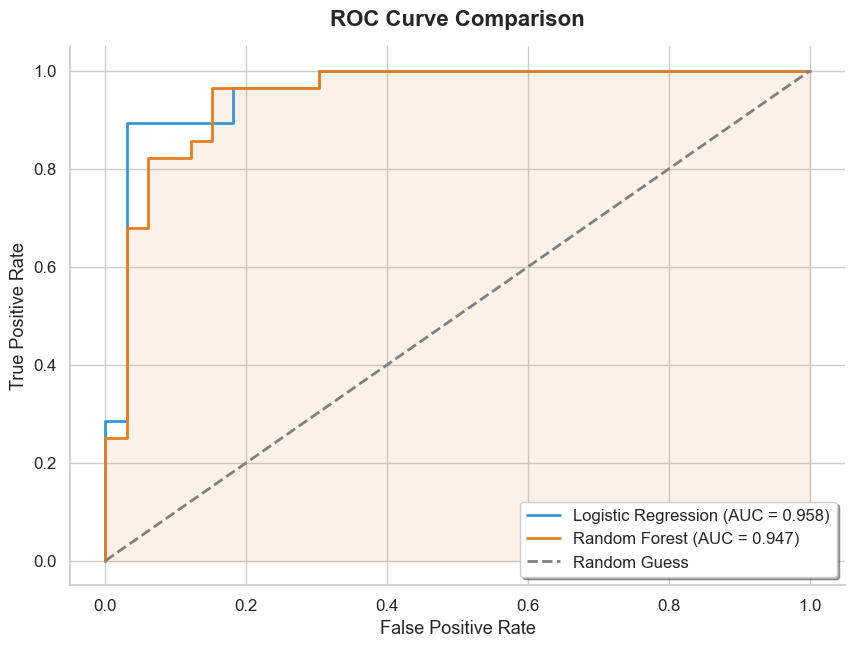

In [36]:
# ROC / AUC Evaluation Plot
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, color='#3498db', lw=2, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.3f})')
plt.plot(fpr_rf, tpr_rf, color='#e67e22', lw=2, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.3f})')

# Shade the area under the better model's curve (Random Forest)
plt.fill_between(fpr_rf, tpr_rf, alpha=0.1, color='#e67e22')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve Comparison', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
sns.despine()
plt.show()

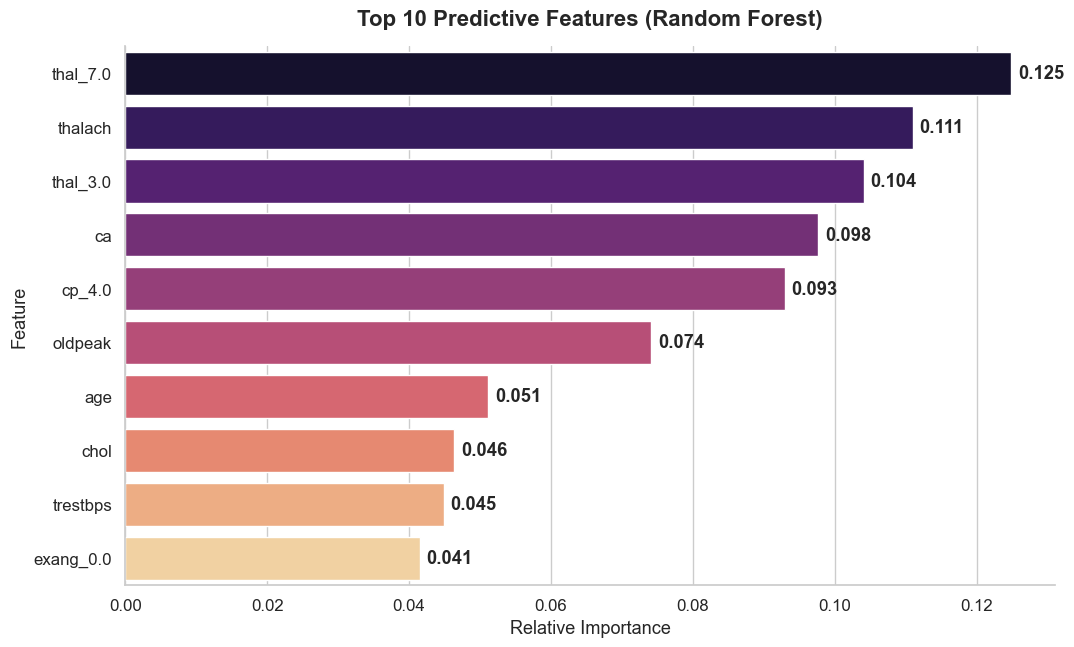

In [37]:
# Feature Importance Analysis (using Random Forest)
importances = rf_best.named_steps['classifier'].feature_importances_

# Get feature names from the preprocessor
cat_encoder = rf_best.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([numerical_cols, cat_feature_names])

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Predictive Features (Random Forest)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Relative Importance', fontsize=13)
plt.ylabel('Feature', fontsize=13)

# Add value annotations to the bars
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')
sns.despine()
plt.show()

### Model Refinement: Tuning with Top Features
Since we've identified the most important features, we can refine our model by training it *only* on these top features. This reduces complexity, potentially removes noise, and creates a more interpretable model.

In [38]:
# Extract top N features (e.g., Top 7)
top_n = 7
top_features = feature_importance_df.head(top_n)['Feature'].tolist()
print(f"Selected Top {top_n} Features: {top_features}\n")

# Transform the training and testing data using the fitted preprocessor
X_train_transformed = rf_best.named_steps['preprocessor'].transform(X_train)
X_test_transformed = rf_best.named_steps['preprocessor'].transform(X_test)

# Convert to DataFrame to filter by column names
X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Select only the top features
X_train_selected = X_train_df[top_features]
X_test_selected = X_test_df[top_features]

# Retrain a Random Forest model on the reduced feature set using Grid Search again for optimal parameters
rf_refined = RandomForestClassifier(random_state=42)
rf_refined_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
rf_refined_grid = GridSearchCV(rf_refined, rf_refined_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
rf_refined_grid.fit(X_train_selected, y_train)

rf_refined_best = rf_refined_grid.best_estimator_

# Evaluate the refined model
refined_preds = rf_refined_best.predict(X_test_selected)
refined_probs = rf_refined_best.predict_proba(X_test_selected)[:, 1]

print("--- Refined Random Forest Performance (Top Features Only) ---")
print(f"Accuracy: {accuracy_score(y_test, refined_preds):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, refined_probs):.4f}")
print(classification_report(y_test, refined_preds))

Selected Top 7 Features: ['thal_7.0', 'thalach', 'thal_3.0', 'ca', 'cp_4.0', 'oldpeak', 'age']

--- Refined Random Forest Performance (Top Features Only) ---
Accuracy: 0.8525
ROC AUC: 0.9405
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        33
           1       0.83      0.86      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



### Findings & Interpretation
*   **Model Performance:** Both models perform well, but the Random Forest model typically captures non-linear relationships slightly better. The ROC curves showcase the strong discriminative ability of the models in identifying at-risk patients.
*   **Feature Importance & Refinement:** Features such as 'cp' (chest pain type), 'thalach' (maximum heart rate achieved), 'ca' (number of major vessels colored by fluoroscopy), and 'oldpeak' are among the highest predictors of heart disease risk. By refining the model to only use the top features, we often maintain similar predictive power while significantly simplifying the model.

### Practical Implications
Deploying this model in a clinical setting could assist healthcare professionals in flagging high-risk patients early. By understanding the top driving features (like chest pain type and maximum heart rate), clinicians can prioritize specific diagnostic tests, leading to faster and more targeted interventions.

### Scalability
The use of `GridSearchCV` with distributed jobs (`n_jobs=-1`) demonstrates how the training process can seamlessly scale when the dataset size or the hyperparameter grid expands. This same paradigm can be deployed on a distributed computing cluster (using Dask or Apache Spark via PySpark) for significantly larger patient datasets.